## Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve, ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
print('✅ Library berhasil di-import')

✅ Library berhasil di-import


In [2]:
# --- Environment & Library Versions (Reproducibility) ---
import sklearn, imblearn
print(f'Python      : {__import__("sys").version.split()[0]}')
print(f'pandas      : {pd.__version__}')
print(f'numpy       : {np.__version__}')
print(f'scikit-learn: {sklearn.__version__}')
print(f'imbalanced-learn: {imblearn.__version__}')
print(f'matplotlib  : {__import__("matplotlib").__version__}')
print('\n✅ Library & versi tercatat untuk reproducibility')

Python      : 3.13.5
pandas      : 2.2.3
numpy       : 2.1.3
scikit-learn: 1.6.1
imbalanced-learn: 0.13.0
matplotlib  : 3.10.0

✅ Library & versi tercatat untuk reproducibility


---
## 1️⃣ Load Dataset

In [3]:
train_df = pd.read_csv('Training.csv')
test_df  = pd.read_csv('Testing.csv')

df = pd.concat([train_df, test_df], ignore_index=True)
print(f'Dataset gabungan : {df.shape[0]} baris, {df.shape[1]} kolom')
print(f'  └─ dari Training.csv : {train_df.shape[0]} baris')
print(f'  └─ dari Testing.csv  : {test_df.shape[0]} baris')

# Split 70% train | 15% val | 15% test  (stratified agar distribusi kelas seimbang)

df_trainval, df_test = train_test_split(
    df, test_size=0.15, random_state=42, stratify=df['Outcome']
)

df_train, df_val = train_test_split(
    df_trainval, test_size=0.15/0.85, random_state=42, stratify=df_trainval['Outcome']
)

print(f'\n📊 Distribusi Split:')
print(f'  Train : {len(df_train):>4} baris ({len(df_train)/len(df)*100:.1f}%)')
print(f'  Val   : {len(df_val):>4} baris ({len(df_val)/len(df)*100:.1f}%)')
print(f'  Test  : {len(df_test):>4} baris ({len(df_test)/len(df)*100:.1f}%)')
print(f'  Total : {len(df):>4} baris')
print(f'\nDistribusi kelas Train   : {dict(df_train["Outcome"].value_counts())}')
print(f'Distribusi kelas Val     : {dict(df_val["Outcome"].value_counts())}')
print(f'Distribusi kelas Test    : {dict(df_test["Outcome"].value_counts())}')
df_train.head()

Dataset gabungan : 2768 baris, 9 kolom
  └─ dari Training.csv : 2460 baris
  └─ dari Testing.csv  : 308 baris

📊 Distribusi Split:
  Train : 1936 baris (69.9%)
  Val   :  416 baris (15.0%)
  Test  :  416 baris (15.0%)
  Total : 2768 baris

Distribusi kelas Train   : {0: np.int64(1199), 1: np.int64(737)}
Distribusi kelas Val     : {0: np.int64(258), 1: np.int64(158)}
Distribusi kelas Test    : {0: np.int64(258), 1: np.int64(158)}


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
1103,4,147,74,25,293,34.9,0.385,30,0
934,4,154,62,31,284,32.8,0.237,23,0
964,3,182,74,0,0,30.5,0.345,29,1
797,3,115,66,39,140,38.1,0.150,28,0
1535,1,151,60,0,0,26.1,0.179,22,0


In [4]:

print('=== CEK MISSING VALUE (df_train) ===')
print(df_train.isnull().sum().to_string())
print('\nTotal missing value:', df_train.isnull().sum().sum())

print('\n=== CEK IMPLAUSIBLE ZEROS (kolom medis) ===')
zero_cols_check = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
zero_df = pd.DataFrame({
    'Jumlah 0 (Train)': [df_train[c].eq(0).sum() for c in zero_cols_check],
    '% dari Total'    : [(df_train[c].eq(0).sum() / len(df_train) * 100).round(2) for c in zero_cols_check],
    'Jumlah 0 (Val)'  : [df_val[c].eq(0).sum() for c in zero_cols_check],
    'Jumlah 0 (Test)' : [df_test[c].eq(0).sum() for c in zero_cols_check],
}, index=zero_cols_check)
print(zero_df.to_string())
print('\n⚠️  Nilai 0 pada kolom di atas tidak mungkin secara medis → akan diganti median training set')

=== CEK MISSING VALUE (df_train) ===
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0

Total missing value: 0

=== CEK IMPLAUSIBLE ZEROS (kolom medis) ===
               Jumlah 0 (Train)  % dari Total  Jumlah 0 (Val)  Jumlah 0 (Test)
Glucose                      17          0.88               1                0
BloodPressure                89          4.60              23               16
SkinThickness               543         28.05             142              125
Insulin                     932         48.14             203              198
BMI                          24          1.24               7                4

⚠️  Nilai 0 pada kolom di atas tidak mungkin secara medis → akan diganti median training set


---
##  Exploratory Data Analysis (EDA)

In [5]:
# --- 2.1 Statistik Deskriptif ---
print('=== STATISTIK DESKRIPTIF ===')
df_train.describe()

=== STATISTIK DESKRIPTIF ===


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,1936.000000,1936.000000,1936.000000,1936.000000,1936.000000,1936.000000,1936.000000,1936.000000,1936.000000
mean,3.822314,121.142562,68.956612,20.854339,80.154442,32.027686,0.489441,32.828512,0.380682
std,3.328592,32.019896,19.130969,15.611778,115.650058,7.770431,0.353906,11.238018,0.485680
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,100.000000,64.000000,0.000000,0.000000,27.300000,0.253750,24.000000,0.000000
50%,3.000000,116.500000,70.000000,23.000000,36.000000,32.200000,0.385000,29.000000,0.000000
75%,6.000000,142.000000,80.000000,33.000000,129.000000,36.525000,0.647000,39.000000,1.000000
max,17.000000,198.000000,122.000000,63.000000,846.000000,67.100000,2.420000,81.000000,1.000000


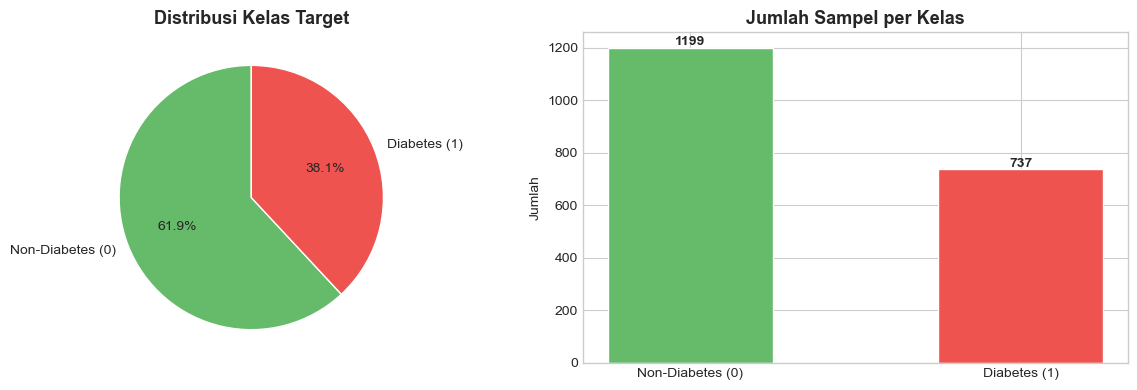

Rasio kelas: 1199:737 → Dataset imbalanced, perlu SMOTE!


In [6]:
# --- 2.2 Distribusi Kelas Target ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df_train['Outcome'].value_counts()
axes[0].pie(counts, labels=['Non-Diabetes (0)', 'Diabetes (1)'],
            autopct='%1.1f%%', colors=['#66bb6a', '#ef5350'],
            startangle=90, wedgeprops=dict(edgecolor='white'))
axes[0].set_title('Distribusi Kelas Target', fontsize=13, fontweight='bold')
axes[1].bar(['Non-Diabetes (0)', 'Diabetes (1)'], counts.values,
            color=['#66bb6a', '#ef5350'], edgecolor='white', width=0.5)
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold')
axes[1].set_title('Jumlah Sampel per Kelas', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Jumlah')
plt.tight_layout()
plt.show()
print(f'Rasio kelas: {counts[0]}:{counts[1]} → Dataset imbalanced, perlu SMOTE!')

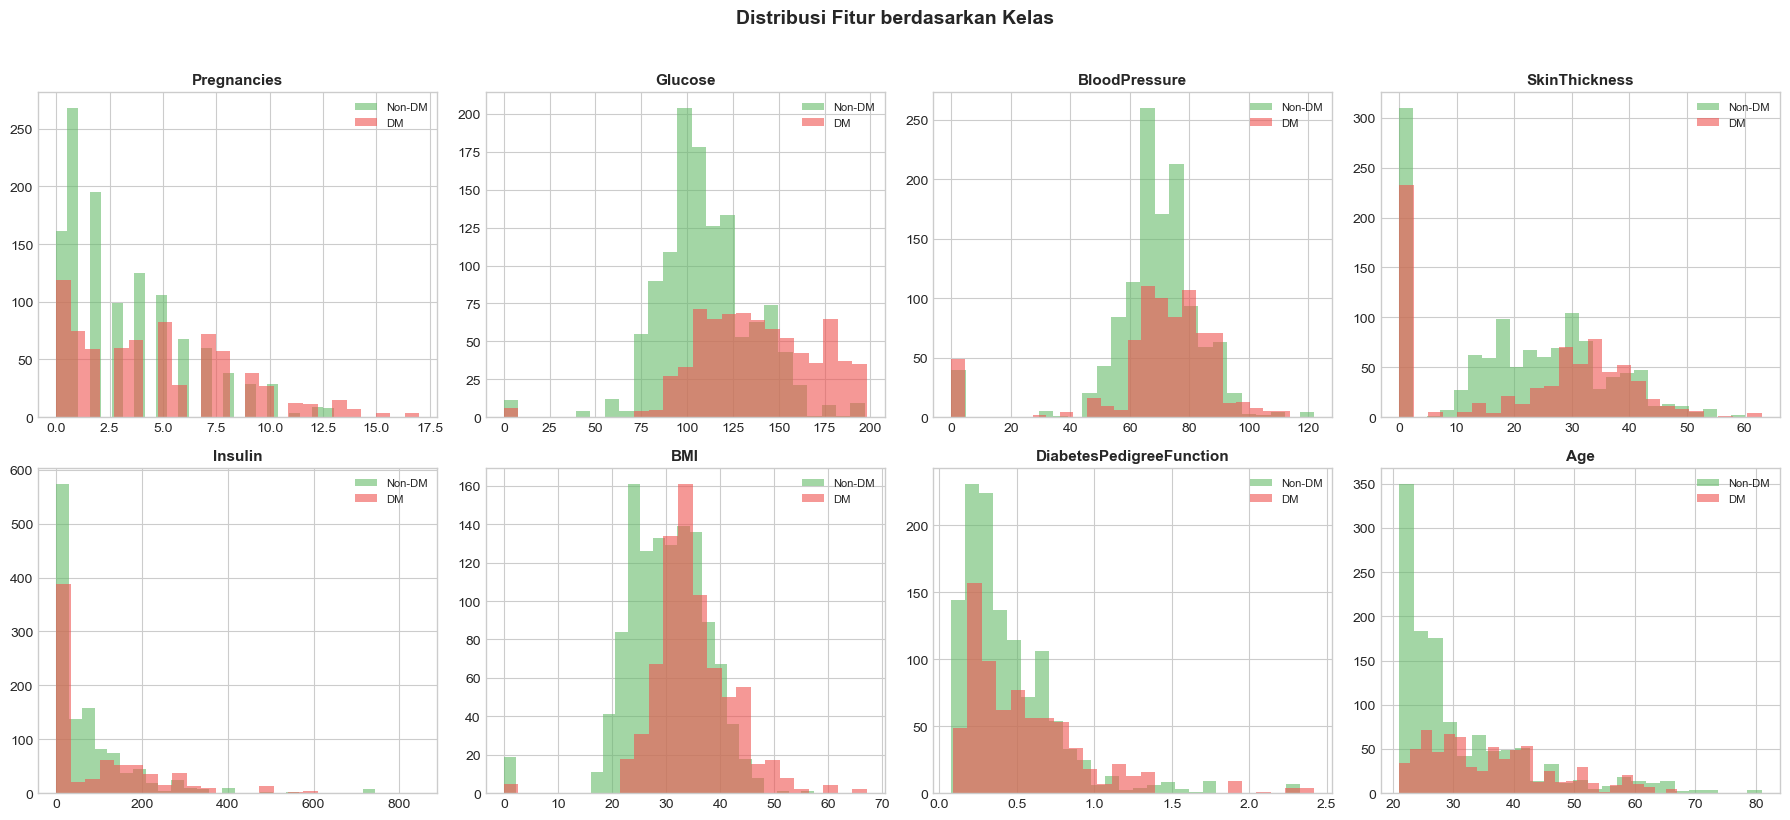

In [7]:
# --- 2.3 Distribusi Fitur per Kelas ---
features = df_train.columns[:-1].tolist()
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(features):
    axes[i].hist(df_train[df_train['Outcome']==0][col], bins=25, alpha=0.6, color='#66bb6a', label='Non-DM')
    axes[i].hist(df_train[df_train['Outcome']==1][col], bins=25, alpha=0.6, color='#ef5350', label='DM')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=8)
plt.suptitle('Distribusi Fitur berdasarkan Kelas', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


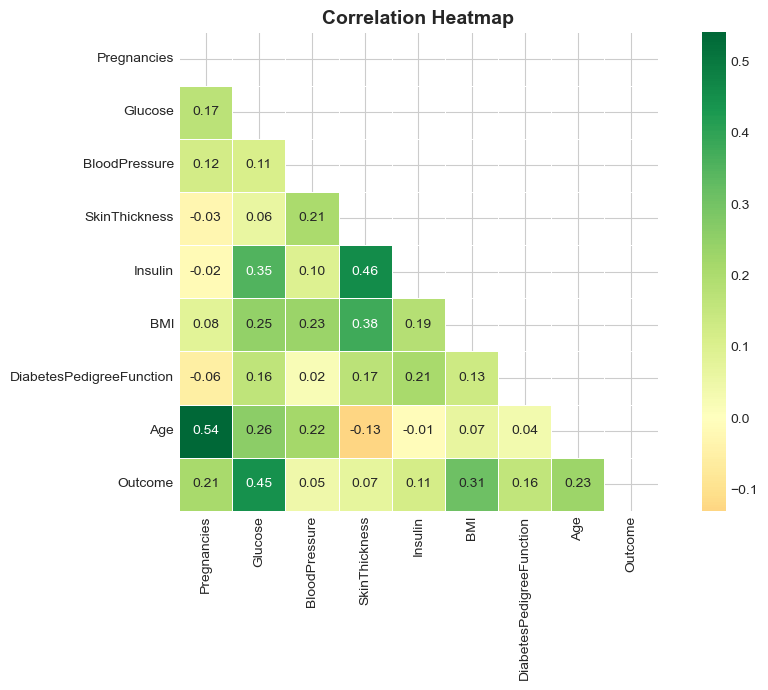

Korelasi dengan Outcome:
Glucose                     0.445099
BMI                         0.309041
Age                         0.231635
Pregnancies                 0.210651
DiabetesPedigreeFunction    0.155906
Insulin                     0.114063
SkinThickness               0.071522
BloodPressure               0.046608
Name: Outcome, dtype: float64


In [8]:
# --- 2.4 Heatmap Korelasi ---
plt.figure(figsize=(10, 7))
corr = df_train.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5, square=True)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('Korelasi dengan Outcome:')
print(corr['Outcome'].drop('Outcome').sort_values(ascending=False))

---
## Data Preparation

In [9]:
# --- 3.1 Tangani Implausible Zeros ---
# Nilai 0 pada kolom berikut tidak mungkin secara medis → ganti dengan median
# median dihitung HANYA dari df_train agar tidak ada data leakage
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
train_clean = df_train.copy()
val_clean   = df_val.copy()
test_clean  = df_test.copy()

for col in zero_cols:
    median_val = train_clean[train_clean[col] != 0][col].median()
    train_clean[col] = train_clean[col].replace(0, median_val)
    val_clean[col]   = val_clean[col].replace(0, median_val)
    test_clean[col]  = test_clean[col].replace(0, median_val)
    print(f'{col}: nilai 0 → median = {median_val:.2f}')
print('\n✅ Implausible zeros ditangani (median dari training set)')

Glucose: nilai 0 → median = 117.00
BloodPressure: nilai 0 → median = 72.00
SkinThickness: nilai 0 → median = 30.00
Insulin: nilai 0 → median = 122.00
BMI: nilai 0 → median = 32.30

✅ Implausible zeros ditangani (median dari training set)


In [10]:
# --- 3.2 Split Fitur dan Target ---
X_train = train_clean.drop('Outcome', axis=1)
y_train = train_clean['Outcome']

X_val   = val_clean.drop('Outcome', axis=1)
y_val   = val_clean['Outcome']

X_test  = test_clean.drop('Outcome', axis=1)
y_test  = test_clean['Outcome']

print(f'X_train : {X_train.shape}')
print(f'X_val   : {X_val.shape}')
print(f'X_test  : {X_test.shape}')

X_train : (1936, 8)
X_val   : (416, 8)
X_test  : (416, 8)


In [11]:
# --- 3.3 StandardScaler ---
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit + transform
X_val_sc   = scaler.transform(X_val)          # transform only
X_test_sc  = scaler.transform(X_test)         # transform only
print('✅ Scaling selesai')
print(f'  Train scaled : {X_train_sc.shape}')
print(f'  Val   scaled : {X_val_sc.shape}')
print(f'  Test  scaled : {X_test_sc.shape}')

✅ Scaling selesai
  Train scaled : (1936, 8)
  Val   scaled : (416, 8)
  Test  scaled : (416, 8)


Distribusi sebelum SMOTE: {0: np.int64(1199), 1: np.int64(737)}
Distribusi setelah SMOTE: {0: np.int64(1199), 1: np.int64(1199)}


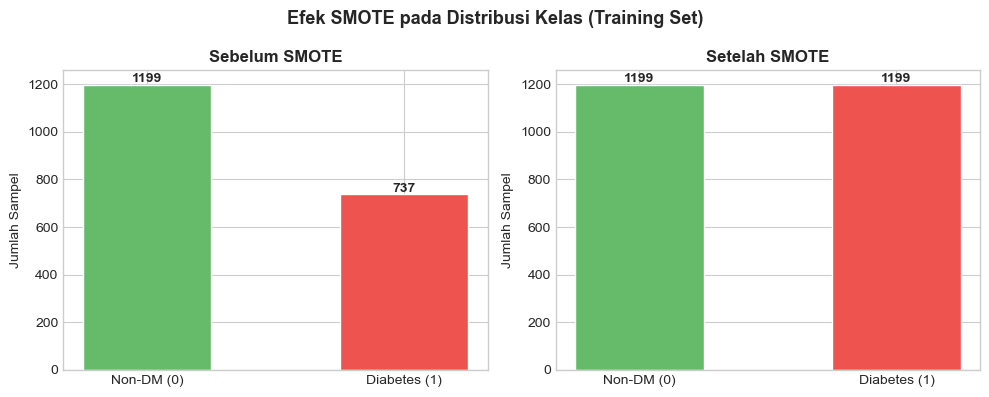

In [12]:
# --- 3.4 SMOTE – Oversampling Kelas Minoritas ---
# SMOTE membuat synthetic samples untuk kelas diabetes (minority)
# agar jumlah kedua kelas seimbang → model tidak bias ke kelas mayoritas
# SMOTE hanya diterapkan di TRAINING SET, TIDAK di val/test set!
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_sc, y_train)

print('Distribusi sebelum SMOTE:', dict(y_train.value_counts()))
print('Distribusi setelah SMOTE:', dict(pd.Series(y_train_smote).value_counts()))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (data, title) in zip(axes, [
    (y_train, 'Sebelum SMOTE'),
    (pd.Series(y_train_smote), 'Setelah SMOTE')
]):
    counts = data.value_counts()
    ax.bar(['Non-DM (0)', 'Diabetes (1)'], [counts.get(0,0), counts.get(1,0)],
           color=['#66bb6a', '#ef5350'], edgecolor='white', width=0.5)
    for i, v in enumerate([counts.get(0,0), counts.get(1,0)]):
        ax.text(i, v+10, str(v), ha='center', fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Jumlah Sampel')
plt.suptitle('Efek SMOTE pada Distribusi Kelas (Training Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



---
## Modelling – 5 Model dengan Improvement


In [13]:
# Helper function: threshold tuning
def tune_threshold(y_true, y_prob, target_recall=0.85):
    """
    Cari threshold terbaik yang memenuhi target recall
    dengan memaksimalkan F1-Score.
    Gunakan VALIDATION SET untuk tuning, bukan test set!
    """
    best_thresh, best_f1 = 0.5, 0.0
    for t in np.arange(0.20, 0.65, 0.01):
        yp = (y_prob >= t).astype(int)
        rec = recall_score(y_true, yp)
        f1  = f1_score(y_true, yp)
        if rec >= target_recall and f1 > best_f1:
            best_f1, best_thresh = f1, t
    return round(best_thresh, 2)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
all_results = []
trained_models = {}
print('✅ Setup selesai, siap training...')

✅ Setup selesai, siap training...


In [14]:
# ============================================================
# MODEL 1: LOGISTIC REGRESSION
# ============================================================
# Model linear klasik yang menggunakan fungsi sigmoid untuk menghasilkan
# probabilitas kelas. class_weight='balanced' membuat model lebih fokus
# pada kelas minoritas (diabetes) saat training.
# GridSearch mencari nilai C (regularization strength) dan solver terbaik.
# ============================================================

lr_base = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_params = {'C': [0.01, 0.1, 1, 10], 'solver': ['lbfgs', 'liblinear']}

lr_gs = GridSearchCV(lr_base, lr_params, cv=cv, scoring='recall', n_jobs=-1)
lr_gs.fit(X_train_smote, y_train_smote)
lr_best = lr_gs.best_estimator_

lr_prob_val = lr_best.predict_proba(X_val_sc)[:, 1]
lr_thresh = tune_threshold(y_val, lr_prob_val)   # tune di val set!
lr_prob = lr_best.predict_proba(X_test_sc)[:, 1]
lr_pred = (lr_prob >= lr_thresh).astype(int)

trained_models['Logistic Regression'] = (lr_best, lr_thresh, lr_prob, lr_pred)
print(f'Best params : {lr_gs.best_params_}')
print(f'Threshold   : {lr_thresh}')
print(f'Accuracy    : {accuracy_score(y_test, lr_pred):.4f}')
print(f'Recall      : {recall_score(y_test, lr_pred):.4f}')
print(f'F1-Score    : {f1_score(y_test, lr_pred):.4f}')
print(f'CV Recall   : {lr_gs.best_score_:.4f} (mean 5-fold GridSearchCV)')

# Metrics di val set (untuk monitoring)
lr_pred_val = (lr_prob_val >= lr_thresh).astype(int)
print(f'--- Val Set Metrics ---')
print(f'Val Accuracy: {accuracy_score(y_val, lr_pred_val):.4f}')
print(f'Val Recall  : {recall_score(y_val, lr_pred_val):.4f}')
print(f'Val F1-Score: {f1_score(y_val, lr_pred_val):.4f}')

Best params : {'C': 0.01, 'solver': 'liblinear'}
Threshold   : 0.4
Accuracy    : 0.6923
Recall      : 0.8481
F1-Score    : 0.6768
CV Recall   : 0.6814 (mean 5-fold GridSearchCV)
--- Val Set Metrics ---
Val Accuracy: 0.7308
Val Recall  : 0.8861
Val F1-Score: 0.7143


In [15]:
# ============================================================
# MODEL 2: K-NEAREST NEIGHBORS (KNN)
# ============================================================
# Mengklasifikasi berdasarkan k tetangga terdekat.
# GridSearch mencari nilai k (n_neighbors) dan skema pembobotan
# (uniform vs distance-weighted) yang optimal.
# Karena KNN tidak punya class_weight, SMOTE menjadi satu-satunya
# mekanisme balancing untuk model ini.
# ============================================================

knn_base = KNeighborsClassifier()
knn_params = {'n_neighbors': [3, 5, 7, 9, 11], 'weights': ['uniform', 'distance']}

knn_gs = GridSearchCV(knn_base, knn_params, cv=cv, scoring='recall', n_jobs=-1)
knn_gs.fit(X_train_smote, y_train_smote)
knn_best = knn_gs.best_estimator_

knn_prob_val = knn_best.predict_proba(X_val_sc)[:, 1]
knn_thresh = tune_threshold(y_val, knn_prob_val)   # tune di val set!
knn_prob = knn_best.predict_proba(X_test_sc)[:, 1]
knn_pred = (knn_prob >= knn_thresh).astype(int)

trained_models['KNN'] = (knn_best, knn_thresh, knn_prob, knn_pred)
print(f'Best params : {knn_gs.best_params_}')
print(f'Threshold   : {knn_thresh}')
print(f'Accuracy    : {accuracy_score(y_test, knn_pred):.4f}')
print(f'Recall      : {recall_score(y_test, knn_pred):.4f}')
print(f'F1-Score    : {f1_score(y_test, knn_pred):.4f}')
print(f'CV Recall   : {knn_gs.best_score_:.4f} (mean 5-fold GridSearchCV)')

# Metrics di val set (untuk monitoring, bukan evaluasi final)
knn_pred_val = (knn_prob_val >= knn_thresh).astype(int)
print(f'--- Val Set Metrics ---')
print(f'Val Accuracy: {accuracy_score(y_val, knn_pred_val):.4f}')
print(f'Val Recall  : {recall_score(y_val, knn_pred_val):.4f}')
print(f'Val F1-Score: {f1_score(y_val, knn_pred_val):.4f}')

Best params : {'n_neighbors': 9, 'weights': 'distance'}
Threshold   : 0.32
Accuracy    : 0.9615
Recall      : 0.9873
F1-Score    : 0.9512
CV Recall   : 0.9817 (mean 5-fold GridSearchCV)
--- Val Set Metrics ---
Val Accuracy: 0.9760
Val Recall  : 0.9810
Val F1-Score: 0.9688


In [16]:
# ============================================================
# MODEL 3: DECISION TREE
# ============================================================
# Model berbasis aturan rekursif yang mudah diinterpretasi.
# class_weight='balanced' + SMOTE membantu menyeimbangkan kelas.
# GridSearch mengoptimalkan max_depth (kedalaman pohon) dan
# min_samples_split untuk mengurangi overfitting.
# ============================================================

dt_base = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt_params = {'max_depth': [3, 4, 5, 6, 7], 'min_samples_split': [2, 5, 10]}

dt_gs = GridSearchCV(dt_base, dt_params, cv=cv, scoring='recall', n_jobs=-1)
dt_gs.fit(X_train_smote, y_train_smote)
dt_best = dt_gs.best_estimator_

dt_prob_val = dt_best.predict_proba(X_val_sc)[:, 1]
dt_thresh = tune_threshold(y_val, dt_prob_val)   # tune di val set!
dt_prob = dt_best.predict_proba(X_test_sc)[:, 1]
dt_pred = (dt_prob >= dt_thresh).astype(int)

trained_models['Decision Tree'] = (dt_best, dt_thresh, dt_prob, dt_pred)
print(f'Best params : {dt_gs.best_params_}')
print(f'Threshold   : {dt_thresh}')
print(f'Accuracy    : {accuracy_score(y_test, dt_pred):.4f}')
print(f'Recall      : {recall_score(y_test, dt_pred):.4f}')
print(f'F1-Score    : {f1_score(y_test, dt_pred):.4f}')
print(f'CV Recall   : {dt_gs.best_score_:.4f} (mean 5-fold GridSearchCV)')

# Metrics di val set (untuk monitoring, bukan evaluasi final)
dt_pred_val = (dt_prob_val >= dt_thresh).astype(int)
print(f'--- Val Set Metrics ---')
print(f'Val Accuracy: {accuracy_score(y_val, dt_pred_val):.4f}')
print(f'Val Recall  : {recall_score(y_val, dt_pred_val):.4f}')
print(f'Val F1-Score: {f1_score(y_val, dt_pred_val):.4f}')

Best params : {'max_depth': 7, 'min_samples_split': 2}
Threshold   : 0.24
Accuracy    : 0.8101
Recall      : 0.9557
F1-Score    : 0.7927
CV Recall   : 0.9458 (mean 5-fold GridSearchCV)
--- Val Set Metrics ---
Val Accuracy: 0.8510
Val Recall  : 0.9367
Val F1-Score: 0.8268


In [17]:
# ============================================================
# MODEL 4: RANDOM FOREST
# ============================================================
# Ensemble dari banyak Decision Tree dengan teknik bagging.
# class_weight='balanced' + SMOTE = double balancing strategy.
# GridSearch mengoptimalkan n_estimators (jumlah pohon), max_depth,
# dan min_samples_split untuk hasil terbaik.
# Biasanya model paling robust di dataset tabular.
# ============================================================

rf_base = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 7, 10, None],
    'min_samples_split': [2, 5]
}

rf_gs = GridSearchCV(rf_base, rf_params, cv=cv, scoring='recall', n_jobs=-1)
rf_gs.fit(X_train_smote, y_train_smote)
rf_best = rf_gs.best_estimator_

rf_prob_val = rf_best.predict_proba(X_val_sc)[:, 1]
rf_thresh = tune_threshold(y_val, rf_prob_val)   # tune di val set!
rf_prob = rf_best.predict_proba(X_test_sc)[:, 1]
rf_pred = (rf_prob >= rf_thresh).astype(int)

trained_models['Random Forest'] = (rf_best, rf_thresh, rf_prob, rf_pred)
print(f'Best params : {rf_gs.best_params_}')
print(f'Threshold   : {rf_thresh}')
print(f'Accuracy    : {accuracy_score(y_test, rf_pred):.4f}')
print(f'Recall      : {recall_score(y_test, rf_pred):.4f}')
print(f'F1-Score    : {f1_score(y_test, rf_pred):.4f}')
print(f'CV Recall   : {rf_gs.best_score_:.4f} (mean 5-fold GridSearchCV)')

# Metrics di val set (untuk monitoring, bukan evaluasi final)
rf_pred_val = (rf_prob_val >= rf_thresh).astype(int)
print(f'--- Val Set Metrics ---')
print(f'Val Accuracy: {accuracy_score(y_val, rf_pred_val):.4f}')
print(f'Val Recall  : {recall_score(y_val, rf_pred_val):.4f}')
print(f'Val F1-Score: {f1_score(y_val, rf_pred_val):.4f}')

Best params : {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Threshold   : 0.57
Accuracy    : 0.9736
Recall      : 0.9747
F1-Score    : 0.9655
CV Recall   : 0.9775 (mean 5-fold GridSearchCV)
--- Val Set Metrics ---
Val Accuracy: 0.9615
Val Recall  : 0.9241
Val F1-Score: 0.9481


In [18]:
# ============================================================
# MODEL 5: SUPPORT VECTOR MACHINE (SVM)
# ============================================================
# Mencari hyperplane optimal dengan margin maksimum.
# Kernel RBF mampu menangani separasi non-linear.
# class_weight='balanced' + SMOTE untuk penanganan imbalance.
# GridSearch mengoptimalkan C (regularization) dan gamma
# (radius pengaruh tiap support vector).
# ============================================================

svm_base = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42)
svm_params = {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto', 0.01]}

svm_gs = GridSearchCV(svm_base, svm_params, cv=cv, scoring='recall', n_jobs=-1)
svm_gs.fit(X_train_smote, y_train_smote)
svm_best = svm_gs.best_estimator_

svm_prob_val = svm_best.predict_proba(X_val_sc)[:, 1]
svm_thresh = tune_threshold(y_val, svm_prob_val)   # tune di val set!
svm_prob = svm_best.predict_proba(X_test_sc)[:, 1]
svm_pred = (svm_prob >= svm_thresh).astype(int)

trained_models['SVM'] = (svm_best, svm_thresh, svm_prob, svm_pred)
print(f'Best params : {svm_gs.best_params_}')
print(f'Threshold   : {svm_thresh}')
print(f'Accuracy    : {accuracy_score(y_test, svm_pred):.4f}')
print(f'Recall      : {recall_score(y_test, svm_pred):.4f}')
print(f'F1-Score    : {f1_score(y_test, svm_pred):.4f}')
print(f'CV Recall   : {svm_gs.best_score_:.4f} (mean 5-fold GridSearchCV)')

# Metrics di val set (untuk monitoring, bukan evaluasi final)
svm_pred_val = (svm_prob_val >= svm_thresh).astype(int)
print(f'--- Val Set Metrics ---')
print(f'Val Accuracy: {accuracy_score(y_val, svm_pred_val):.4f}')
print(f'Val Recall  : {recall_score(y_val, svm_pred_val):.4f}')
print(f'Val F1-Score: {f1_score(y_val, svm_pred_val):.4f}')

Best params : {'C': 10, 'gamma': 'scale'}
Threshold   : 0.42
Accuracy    : 0.8990
Recall      : 0.9304
F1-Score    : 0.8750
CV Recall   : 0.9366 (mean 5-fold GridSearchCV)
--- Val Set Metrics ---
Val Accuracy: 0.9062
Val Recall  : 0.8671
Val F1-Score: 0.8754


### 📈 5.0 Learning Curve – Cek Overfitting / Underfitting

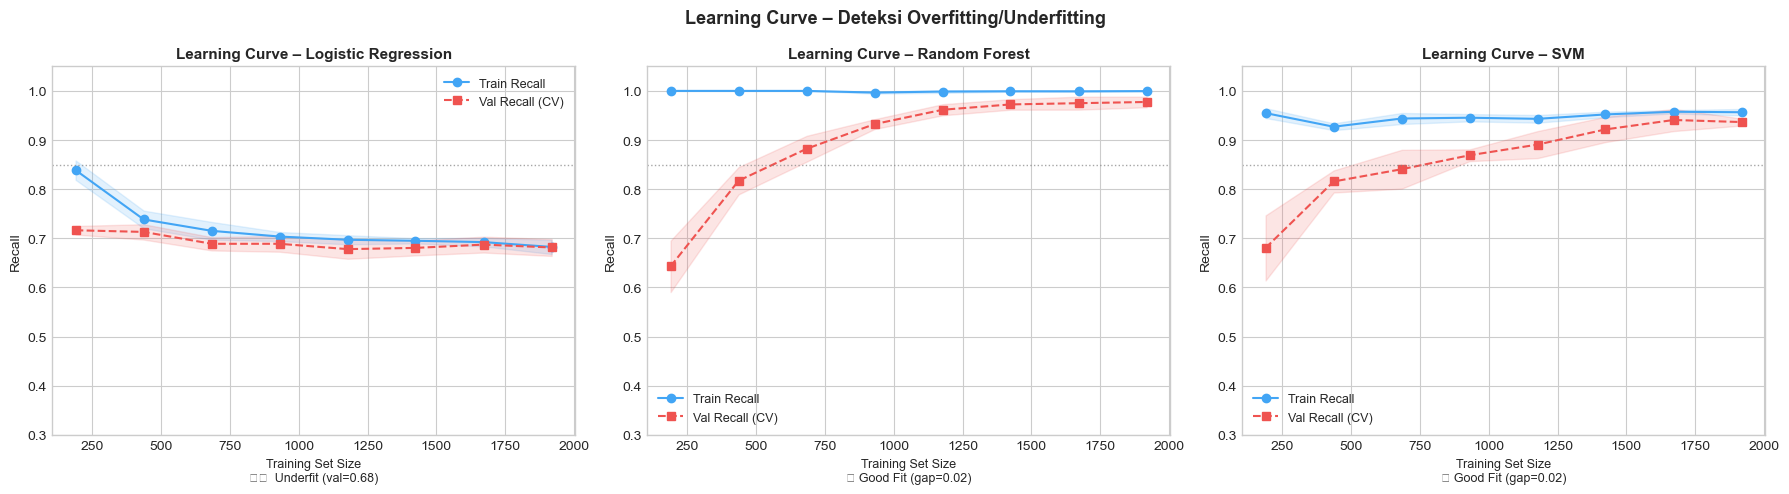

In [19]:
# --- 5.0 Learning Curve – Deteksi Overfitting / Underfitting ---
# (Training scores vs Cross-Val scores on SMOTE'd training set)
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
lc_models = {k: v for k, v in trained_models.items()
             if k in ['Logistic Regression', 'Random Forest', 'SVM']}

for ax, (name, (model, thresh, prob, pred)) in zip(axes, lc_models.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train_smote, y_train_smote,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='recall', n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 8)
    )
    tr_mean, tr_std = train_scores.mean(axis=1), train_scores.std(axis=1)
    vl_mean, vl_std = val_scores.mean(axis=1),   val_scores.std(axis=1)

    ax.plot(train_sizes, tr_mean, 'o-', color='#42a5f5', label='Train Recall')
    ax.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std, alpha=0.15, color='#42a5f5')
    ax.plot(train_sizes, vl_mean, 's--', color='#ef5350', label='Val Recall (CV)')
    ax.fill_between(train_sizes, vl_mean - vl_std, vl_mean + vl_std, alpha=0.15, color='#ef5350')
    ax.axhline(0.85, color='gray', linestyle=':', lw=1, alpha=0.7)
    ax.set_title(f'Learning Curve – {name}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Recall')
    ax.legend(fontsize=9)
    ax.set_ylim(0.3, 1.05)

    gap = tr_mean[-1] - vl_mean[-1]
    if gap > 0.1:
        diagnosis = f'⚠️  Overfit (gap={gap:.2f})'
    elif vl_mean[-1] < 0.7:
        diagnosis = f'⚠️  Underfit (val={vl_mean[-1]:.2f})'
    else:
        diagnosis = f'✅ Good Fit (gap={gap:.2f})'
    ax.set_xlabel(f'Training Set Size\n{diagnosis}', fontsize=9)

plt.suptitle('Learning Curve – Deteksi Overfitting/Underfitting', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
##  Evaluation

In [20]:
# --- 5.1 Tabel Perbandingan Semua Model (Train | Val | Test) ---
# ⚠️  LEGEND SET:
#   Train  = metrik di training set (setelah SMOTE) → cek overfit
#   Val    = metrik di validation set (threshold di-tune di sini)
#   Test   = metrik di test set (evaluasi FINAL, hanya dibaca sekali)

results = []
for name, (model, thresh, prob_test, pred_test) in trained_models.items():
    # --- Train set predictions (pakai scaled train, sebelum SMOTE untuk fairness) ---
    prob_train = model.predict_proba(X_train_sc)[:, 1]
    pred_train = (prob_train >= thresh).astype(int)

    # --- Val set predictions ---
    prob_val = model.predict_proba(X_val_sc)[:, 1]
    pred_val = (prob_val >= thresh).astype(int)

    results.append({
        'Model'         : name,
        'Threshold'     : thresh,
        # ── TRAIN ──
        'Train Acc'     : round(accuracy_score(y_train, pred_train), 4),
        'Train Recall'  : round(recall_score(y_train, pred_train), 4),
        'Train F1'      : round(f1_score(y_train, pred_train), 4),
        # ── VAL ──
        'Val Acc'       : round(accuracy_score(y_val, pred_val), 4),
        'Val Recall'    : round(recall_score(y_val, pred_val), 4),
        'Val F1'        : round(f1_score(y_val, pred_val), 4),
        # ── TEST ──
        'Test Acc'      : round(accuracy_score(y_test, pred_test), 4),
        'Test Precision': round(precision_score(y_test, pred_test), 4),
        'Test Recall'   : round(recall_score(y_test, pred_test), 4),
        'Test F1'       : round(f1_score(y_test, pred_test), 4),
        'Test ROC-AUC'  : round(roc_auc_score(y_test, prob_test), 4),
    })

results_df = pd.DataFrame(results).set_index('Model')

# ── Print tabel per set ──────────────────────────────────────────────────
print('=' * 65)
print('📊 TRAIN SET METRICS  (cek apakah model overfit)')
print('=' * 65)
print(results_df[['Threshold','Train Acc','Train Recall','Train F1']].to_string())

print('\n' + '=' * 65)
print('🔧 VALIDATION SET METRICS  (dipakai untuk threshold tuning)')
print('=' * 65)
print(results_df[['Threshold','Val Acc','Val Recall','Val F1']].to_string())

print('\n' + '=' * 65)
print('🏁 TEST SET METRICS  ← EVALUASI FINAL (hanya dibaca sekali!)')
print('=' * 65)
print(results_df[['Threshold','Test Acc','Test Precision','Test Recall','Test F1','Test ROC-AUC']].to_string())

best_recall_model = results_df['Test Recall'].idxmax()
best_f1_model     = results_df['Test F1'].idxmax()
print(f'\n🏆 Test Recall tertinggi  : {best_recall_model} ({results_df.loc[best_recall_model, "Test Recall"]:.4f})')
print(f'🏆 Test F1 tertinggi      : {best_f1_model} ({results_df.loc[best_f1_model, "Test F1"]:.4f})')
print('\n📌 Threshold di-tune dari VAL set → evaluasi final pakai TEST set')


📊 TRAIN SET METRICS  (cek apakah model overfit)
                     Threshold  Train Acc  Train Recall  Train F1
Model                                                            
Logistic Regression       0.40     0.6906        0.8535    0.6774
KNN                       0.32     1.0000        1.0000    1.0000
Decision Tree             0.24     0.8373        0.9796    0.8209
Random Forest             0.57     0.9907        0.9946    0.9879
SVM                       0.42     0.9323        0.9593    0.9152

🔧 VALIDATION SET METRICS  (dipakai untuk threshold tuning)
                     Threshold  Val Acc  Val Recall  Val F1
Model                                                      
Logistic Regression       0.40   0.7308      0.8861  0.7143
KNN                       0.32   0.9760      0.9810  0.9688
Decision Tree             0.24   0.8510      0.9367  0.8268
Random Forest             0.57   0.9615      0.9241  0.9481
SVM                       0.42   0.9062      0.8671  0.8754

🏁 TEST SE

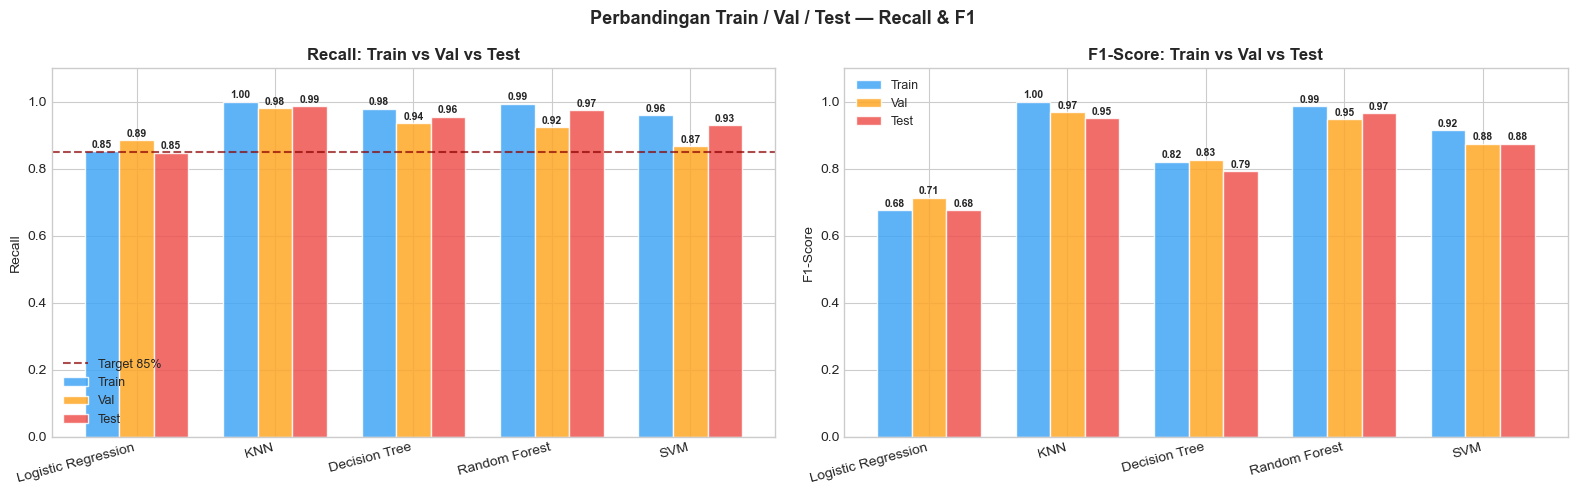

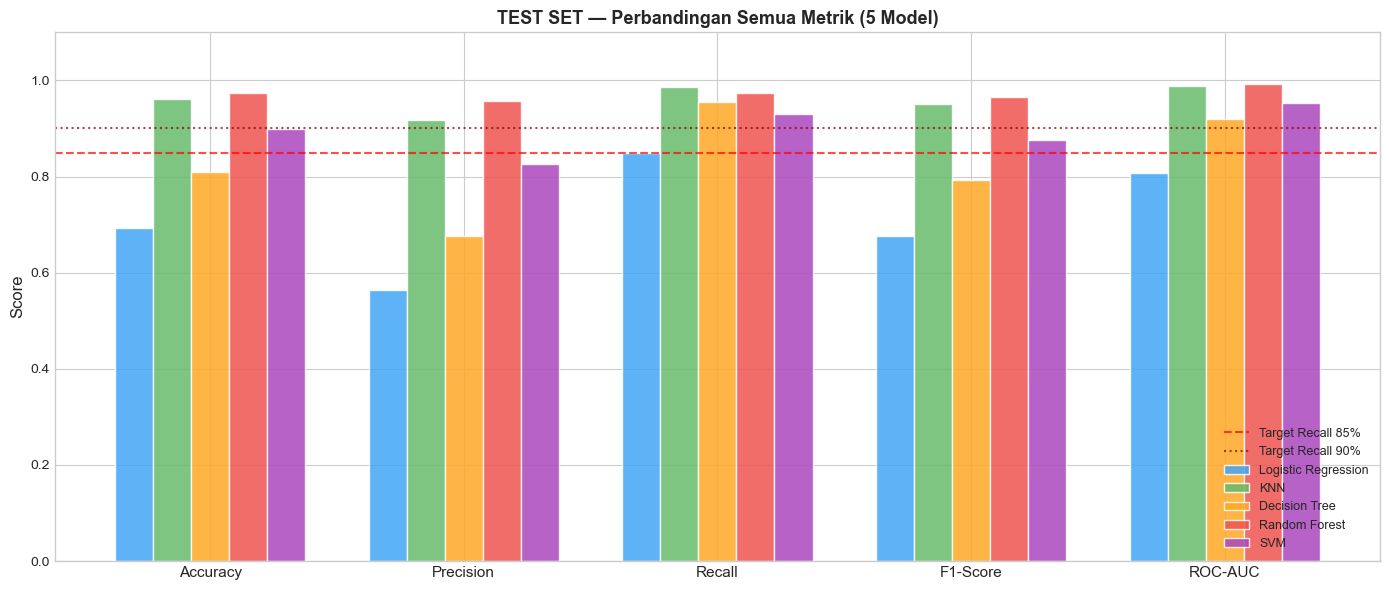

In [21]:
# --- 5.2 Visualisasi Perbandingan Train / Val / Test per Model ---

# 5.2a  Bar chart Recall Train vs Val vs Test (deteksi overfit)
model_names = list(results_df.index)
x = np.arange(len(model_names))
w = 0.25

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# -- Recall comparison --
ax = axes[0]
b1 = ax.bar(x - w, results_df['Train Recall'], w, label='Train',  color='#42a5f5', alpha=0.85, edgecolor='white')
b2 = ax.bar(x,     results_df['Val Recall'],   w, label='Val',    color='#ffa726', alpha=0.85, edgecolor='white')
b3 = ax.bar(x + w, results_df['Test Recall'],  w, label='Test',   color='#ef5350', alpha=0.85, edgecolor='white')
ax.axhline(0.85, color='darkred', linestyle='--', lw=1.5, alpha=0.7, label='Target 85%')
ax.set_xticks(x); ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.set_ylim(0, 1.1); ax.set_ylabel('Recall'); ax.set_title('Recall: Train vs Val vs Test', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
for bar in list(b1)+list(b2)+list(b3):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{bar.get_height():.2f}', ha='center', fontsize=7.5, fontweight='bold')

# -- F1 comparison --
ax = axes[1]
b1 = ax.bar(x - w, results_df['Train F1'], w, label='Train', color='#42a5f5', alpha=0.85, edgecolor='white')
b2 = ax.bar(x,     results_df['Val F1'],   w, label='Val',   color='#ffa726', alpha=0.85, edgecolor='white')
b3 = ax.bar(x + w, results_df['Test F1'],  w, label='Test',  color='#ef5350', alpha=0.85, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.set_ylim(0, 1.1); ax.set_ylabel('F1-Score'); ax.set_title('F1-Score: Train vs Val vs Test', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
for bar in list(b1)+list(b2)+list(b3):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{bar.get_height():.2f}', ha='center', fontsize=7.5, fontweight='bold')

plt.suptitle('Perbandingan Train / Val / Test — Recall & F1', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 5.2b  Bar chart semua metrik Test Set (evaluasi final 5 model)
metrics_test = ['Test Acc', 'Test Precision', 'Test Recall', 'Test F1', 'Test ROC-AUC']
x2 = np.arange(len(metrics_test))
width2 = 0.15
colors5 = ['#42a5f5', '#66bb6a', '#ffa726', '#ef5350', '#ab47bc']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (name, row) in enumerate(results_df.iterrows()):
    bars = ax.bar(x2 + i*width2, [row[m] for m in metrics_test],
                  width2, label=name, color=colors5[i], alpha=0.85, edgecolor='white')
ax.axhline(0.85, color='red', linestyle='--', lw=1.5, alpha=0.7, label='Target Recall 85%')
ax.axhline(0.90, color='darkred', linestyle=':', lw=1.5, alpha=0.7, label='Target Recall 90%')
ax.set_xticks(x2 + width2*2)
ax.set_xticklabels(['Accuracy','Precision','Recall','F1-Score','ROC-AUC'], fontsize=11)
ax.set_ylim(0, 1.1); ax.set_ylabel('Score', fontsize=12)
ax.set_title('TEST SET — Perbandingan Semua Metrik (5 Model)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()


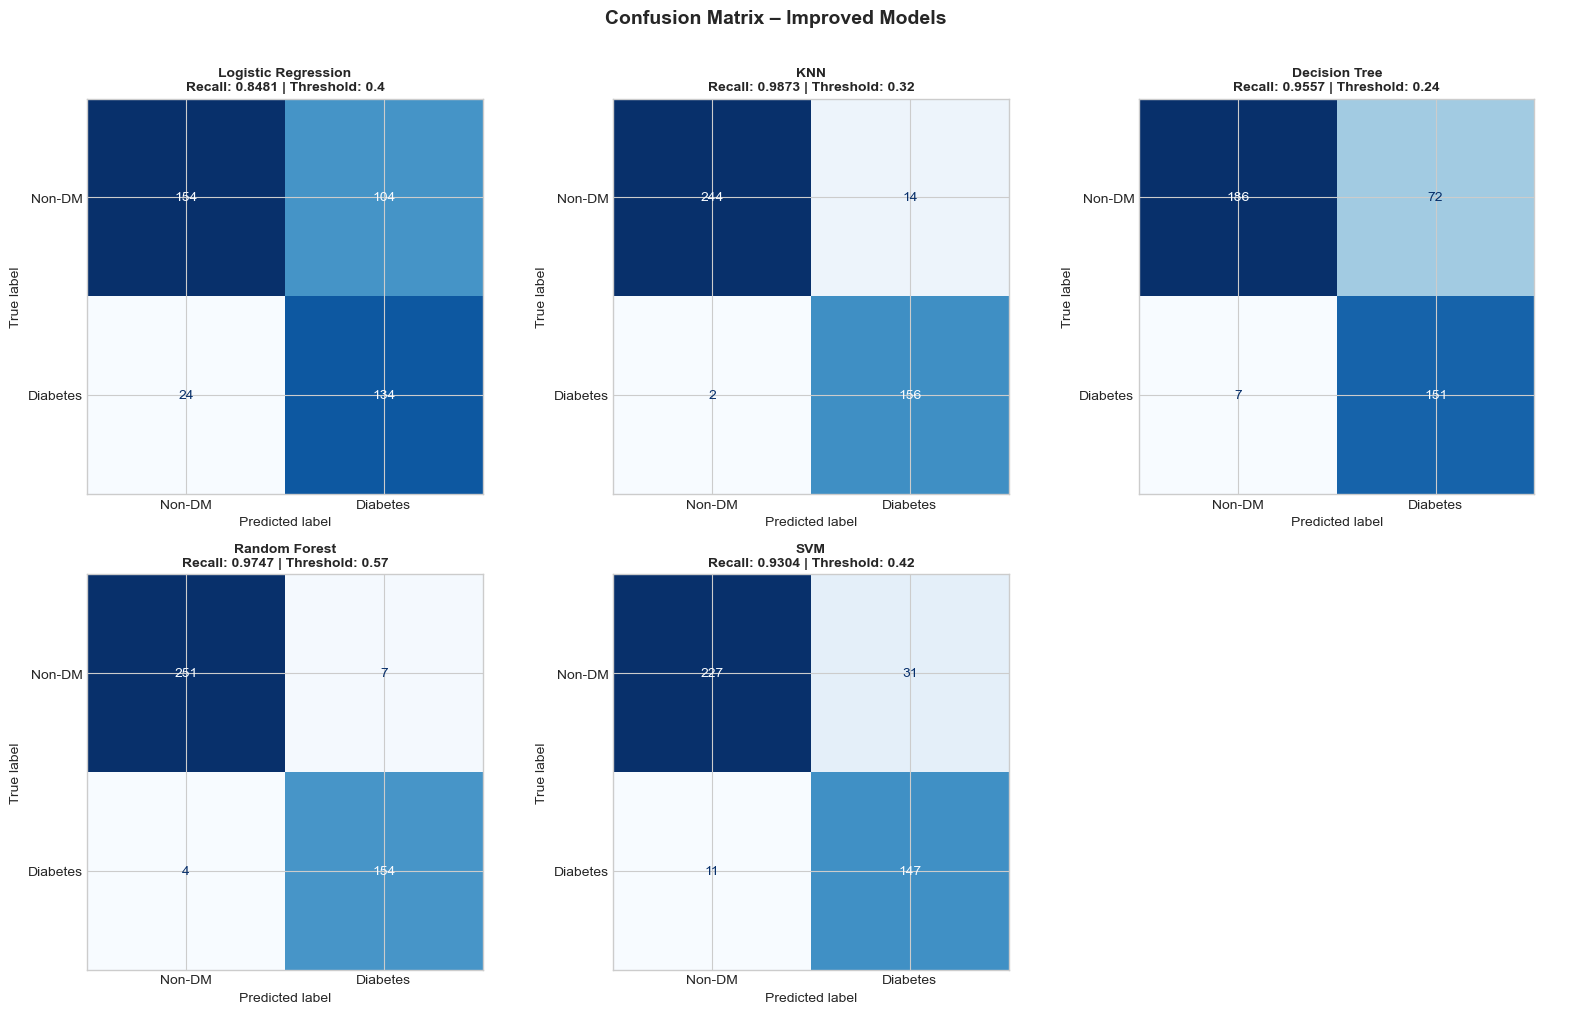

In [22]:
# --- 5.3 Confusion Matrix – Semua Model ---
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (name, (model, thresh, prob, pred)) in enumerate(trained_models.items()):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-DM', 'Diabetes'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    rec = recall_score(y_test, pred)
    axes[i].set_title(f'{name}\nRecall: {rec:.4f} | Threshold: {thresh}',
                      fontsize=10, fontweight='bold')

axes[-1].axis('off')
plt.suptitle('Confusion Matrix – Improved Models', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

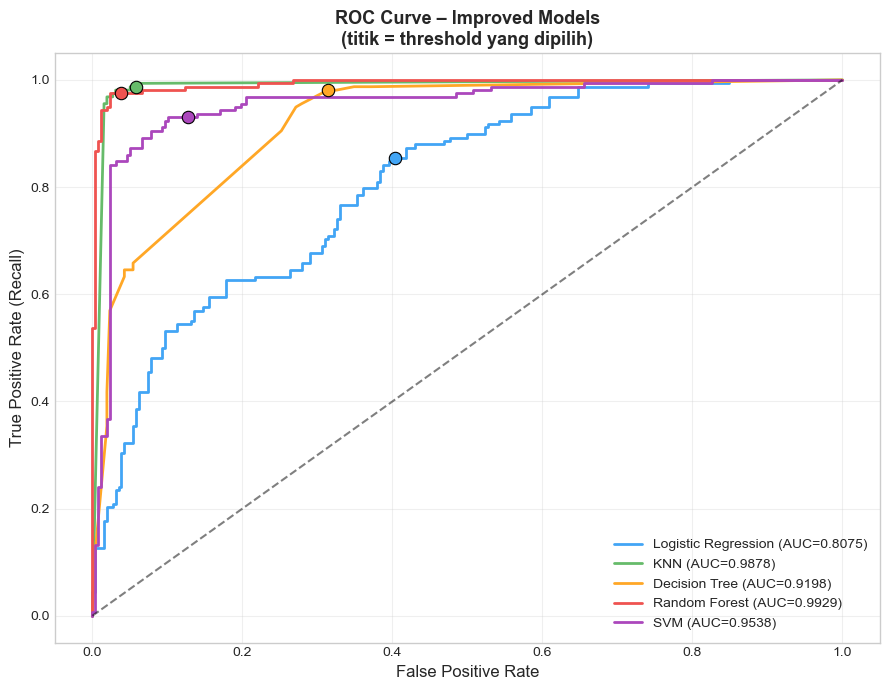

In [23]:
# --- 5.4 ROC Curve ---
plt.figure(figsize=(9, 7))
colors_roc = ['#42a5f5', '#66bb6a', '#ffa726', '#ef5350', '#ab47bc']

for (name, (model, thresh, prob, pred)), color in zip(trained_models.items(), colors_roc):
    fpr, tpr, thresholds = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.4f})')
    # Tandai titik threshold yang dipilih
    idx = np.argmin(np.abs(thresholds - thresh))
    plt.scatter(fpr[idx], tpr[idx], color=color, s=80, zorder=5, edgecolors='black', linewidths=0.8)

plt.plot([0,1],[0,1], 'k--', lw=1.5, alpha=0.5)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve – Improved Models\n(titik = threshold yang dipilih)', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

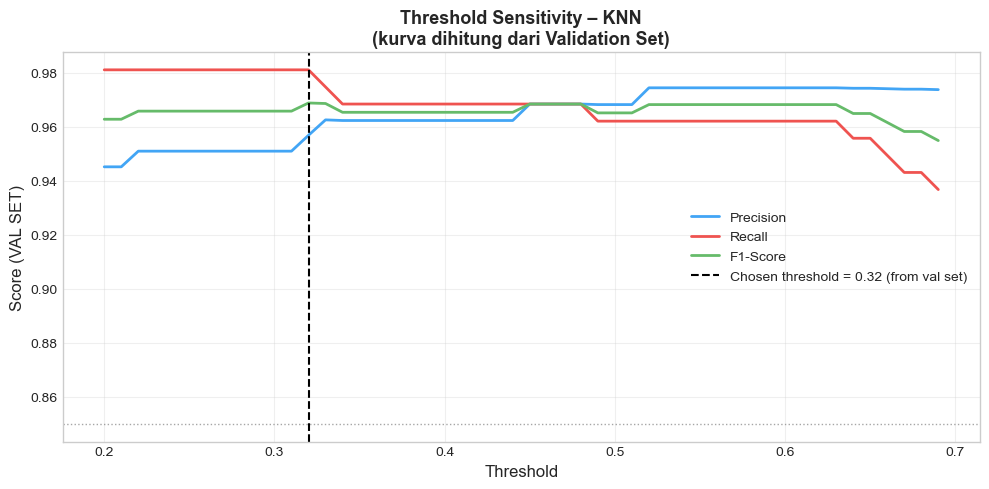

In [24]:
# --- 5.5 Threshold Sensitivity Analysis (Model Terbaik) ---
# Kurva ini menggunakan VAL SET (sama dengan set yang dipakai saat threshold tuning)
# Titik vertikal = threshold optimal yang dipilih dari val set
best_name = best_recall_model
best_model = trained_models[best_name][0]
chosen_thresh = trained_models[best_name][1]
best_prob_val = best_model.predict_proba(X_val_sc)[:, 1]  # VAL SET

thresholds = np.arange(0.20, 0.70, 0.01)
precisions, recalls, f1s = [], [], []
for t in thresholds:
    yp = (best_prob_val >= t).astype(int)
    precisions.append(precision_score(y_val, yp, zero_division=0))
    recalls.append(recall_score(y_val, yp))
    f1s.append(f1_score(y_val, yp, zero_division=0))

plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions, label='Precision', color='#42a5f5', lw=2)
plt.plot(thresholds, recalls,   label='Recall',    color='#ef5350', lw=2)
plt.plot(thresholds, f1s,       label='F1-Score',  color='#66bb6a', lw=2)
plt.axvline(chosen_thresh, color='black', linestyle='--', lw=1.5,
            label=f'Chosen threshold = {chosen_thresh} (from val set)')
plt.axhline(0.85, color='gray', linestyle=':', lw=1, alpha=0.7)
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Score (VAL SET)', fontsize=12)
plt.title(f'Threshold Sensitivity – {best_name}\n(kurva dihitung dari Validation Set)',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


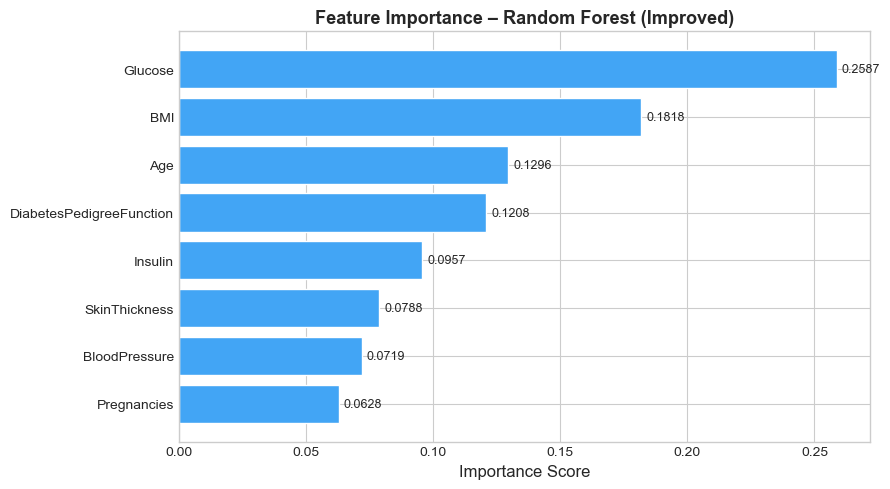

In [25]:
# --- 5.6 Feature Importance (Random Forest) ---
rf_model_final = trained_models['Random Forest'][0]
importances = rf_model_final.feature_importances_
feat_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 5))
bars = plt.barh(feat_df['Feature'], feat_df['Importance'], color='#42a5f5', edgecolor='white')
for bar, val in zip(bars, feat_df['Importance']):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)
plt.xlabel('Importance Score', fontsize=12)
plt.title('Feature Importance – Random Forest (Improved)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [26]:
# --- 5.7 Classification Report – Model dengan Test Recall Tertinggi ---
best_model_obj  = trained_models[best_recall_model][0]
best_thresh_obj = trained_models[best_recall_model][1]
best_prob_test  = trained_models[best_recall_model][2]
best_pred_test  = trained_models[best_recall_model][3]
best_pred_val   = (best_model_obj.predict_proba(X_val_sc)[:, 1] >= best_thresh_obj).astype(int)
best_pred_train = (best_model_obj.predict_proba(X_train_sc)[:, 1] >= best_thresh_obj).astype(int)

print(f'📋 CLASSIFICATION REPORT – {best_recall_model}')
print(f'   Threshold = {best_thresh_obj} (dipilih dari validation set)')

print('\n🔵 TRAIN SET:')
print('='*55)
print(classification_report(y_train, best_pred_train, target_names=['Non-Diabetes','Diabetes']))

print('🟡 VALIDATION SET:')
print('='*55)
print(classification_report(y_val, best_pred_val, target_names=['Non-Diabetes','Diabetes']))

print('🔴 TEST SET (evaluasi final):')
print('='*55)
print(classification_report(y_test, best_pred_test, target_names=['Non-Diabetes','Diabetes']))


📋 CLASSIFICATION REPORT – KNN
   Threshold = 0.32 (dipilih dari validation set)

🔵 TRAIN SET:
              precision    recall  f1-score   support

Non-Diabetes       1.00      1.00      1.00      1199
    Diabetes       1.00      1.00      1.00       737

    accuracy                           1.00      1936
   macro avg       1.00      1.00      1.00      1936
weighted avg       1.00      1.00      1.00      1936

🟡 VALIDATION SET:
              precision    recall  f1-score   support

Non-Diabetes       0.99      0.97      0.98       258
    Diabetes       0.96      0.98      0.97       158

    accuracy                           0.98       416
   macro avg       0.97      0.98      0.97       416
weighted avg       0.98      0.98      0.98       416

🔴 TEST SET (evaluasi final):
              precision    recall  f1-score   support

Non-Diabetes       0.99      0.95      0.97       258
    Diabetes       0.92      0.99      0.95       158

    accuracy                           0.

In [27]:
# --- 5.8 Ringkasan Train / Val / Test — Tabel Lengkap per Model ---
# Satu tabel yang menunjukkan performa di ketiga set sekaligus
# → mudah mendeteksi overfit (Train >> Val/Test) atau underfit (semua rendah)

summary_rows = []
for name, (model, thresh, prob_test, pred_test) in trained_models.items():
    prob_tr  = model.predict_proba(X_train_sc)[:, 1]
    pred_tr  = (prob_tr  >= thresh).astype(int)
    prob_vl  = model.predict_proba(X_val_sc)[:, 1]
    pred_vl  = (prob_vl  >= thresh).astype(int)

    for split, yt, yp, yprob in [
        ('Train', y_train, pred_tr, prob_tr),
        ('Val',   y_val,   pred_vl, prob_vl),
        ('Test',  y_test,  pred_test, prob_test),
    ]:
        summary_rows.append({
            'Model'    : name,
            'Set'      : split,
            'Threshold': thresh,
            'Accuracy' : round(accuracy_score(yt, yp), 4),
            'Precision': round(precision_score(yt, yp), 4),
            'Recall'   : round(recall_score(yt, yp), 4),
            'F1-Score' : round(f1_score(yt, yp), 4),
            'ROC-AUC'  : round(roc_auc_score(yt, yprob), 4),
        })

summary_df = pd.DataFrame(summary_rows).set_index(['Model', 'Set'])

print('📊 RINGKASAN LENGKAP — TRAIN | VAL | TEST per Model')
print('=' * 75)
print(summary_df.to_string())
print('=' * 75)
print('\n💡 Cara baca:')
print('  Train ≈ Val ≈ Test  → model generalizes well ✅')
print('  Train >> Val/Test   → overfit ⚠️')
print('  Semua rendah        → underfit ⚠️')
print('  Val ≠ Test jauh     → threshold tuning kurang stabil ⚠️')


📊 RINGKASAN LENGKAP — TRAIN | VAL | TEST per Model
                           Threshold  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model               Set                                                             
Logistic Regression Train       0.40    0.6906     0.5616  0.8535    0.6774   0.8191
                    Val         0.40    0.7308     0.5983  0.8861    0.7143   0.8252
                    Test        0.40    0.6923     0.5630  0.8481    0.6768   0.8075
KNN                 Train       0.32    1.0000     1.0000  1.0000    1.0000   1.0000
                    Val         0.32    0.9760     0.9568  0.9810    0.9688   0.9964
                    Test        0.32    0.9615     0.9176  0.9873    0.9512   0.9878
Decision Tree       Train       0.24    0.8373     0.7065  0.9796    0.8209   0.9461
                    Val         0.24    0.8510     0.7400  0.9367    0.8268   0.9317
                    Test        0.24    0.8101     0.6771  0.9557    0.7927   0.9198
Random Forest 

📈 PERBANDINGAN BEFORE vs AFTER IMPROVEMENT
                     Recall Before  Recall After  F1 Before  F1 After  Recall Δ    F1 Δ
Model                                                                                  
Logistic Regression         0.5161        0.8481     0.6477    0.6768    0.3320  0.0291
KNN                         0.4624        0.9873     0.5741    0.9512    0.5249  0.3771
Decision Tree               0.5699        0.9557     0.6255    0.7927    0.3858  0.1672
Random Forest               0.5484        0.9747     0.6593    0.9655    0.4263  0.3062
SVM                         0.5269        0.9304     0.6378    0.8750    0.4035  0.2372


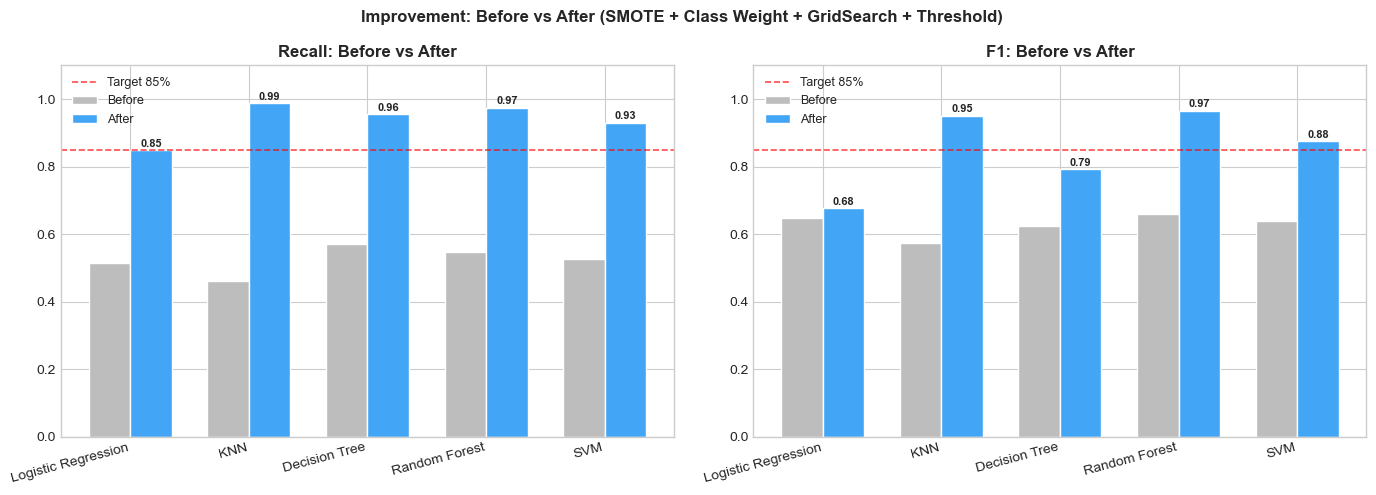

In [28]:
# --- 5.8 Perbandingan Before vs After Improvement ---
# Baseline (tanpa improvement) vs model terbaik yang sudah diimprove
baseline = {
    'Logistic Regression': {'Accuracy':0.7987, 'Recall':0.5161, 'F1':0.6477, 'ROC-AUC':0.8646},
    'KNN':                 {'Accuracy':0.7013, 'Recall':0.4624, 'F1':0.5741, 'ROC-AUC':0.7161},
    'Decision Tree':       {'Accuracy':0.7045, 'Recall':0.5699, 'F1':0.6255, 'ROC-AUC':0.7718},
    'Random Forest':       {'Accuracy':0.7987, 'Recall':0.5484, 'F1':0.6593, 'ROC-AUC':0.8598},
    'SVM':                 {'Accuracy':0.7825, 'Recall':0.5269, 'F1':0.6378, 'ROC-AUC':0.8418},
}

compare_data = []
for name in trained_models:
    _, _, prob, pred = trained_models[name]
    compare_data.append({
        'Model'          : name,
        'Recall Before'  : baseline[name]['Recall'],
        'Recall After'   : round(recall_score(y_test, pred), 4),
        'F1 Before'      : baseline[name]['F1'],
        'F1 After'       : round(f1_score(y_test, pred), 4),
    })
    
compare_df = pd.DataFrame(compare_data).set_index('Model')
compare_df['Recall Δ'] = (compare_df['Recall After'] - compare_df['Recall Before']).round(4)
compare_df['F1 Δ']     = (compare_df['F1 After'] - compare_df['F1 Before']).round(4)

print('📈 PERBANDINGAN BEFORE vs AFTER IMPROVEMENT')
print('='*65)
print(compare_df.to_string())

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(compare_df))
w = 0.35

for ax, metric in zip(axes, ['Recall', 'F1']):
    b1 = ax.bar(x - w/2, compare_df[f'{metric} Before'], w, label='Before', color='#bdbdbd', edgecolor='white')
    b2 = ax.bar(x + w/2, compare_df[f'{metric} After'],  w, label='After',  color='#42a5f5', edgecolor='white')
    ax.axhline(0.85, color='red', linestyle='--', lw=1.2, alpha=0.7, label='Target 85%')
    ax.set_xticks(x)
    ax.set_xticklabels(compare_df.index, rotation=15, ha='right')
    ax.set_ylim(0, 1.1)
    ax.set_title(f'{metric}: Before vs After', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    for bar in b2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.2f}', ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Improvement: Before vs After (SMOTE + Class Weight + GridSearch + Threshold)', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6️⃣ Save Model & Artefak

Simpan semua model yang sudah dilatih beserta scaler dan metadata threshold ke folder `models/`  
agar bisa langsung di-load oleh Flask app tanpa perlu training ulang.

| File | Isi |
|---|---|
| `scaler.pkl` | StandardScaler yang di-fit di training set |
| `logistic_regression.pkl` | Model LR terbaik (GridSearchCV) |
| `knn.pkl` | Model KNN terbaik |
| `decision_tree.pkl` | Model DT terbaik |
| `random_forest.pkl` | Model RF terbaik |
| `svm.pkl` | Model SVM terbaik |
| `metadata.json` | Threshold + metrik semua model + nama fitur |

In [29]:
# ============================================================
# 6. SAVE MODEL & ARTEFAK
# ============================================================
# Simpan scaler, semua model, dan metadata (threshold + metrik)
# ke folder models/ untuk dipakai oleh Flask app.
# ============================================================

import joblib, os, json

MODELS_DIR = 'models'
os.makedirs(MODELS_DIR, exist_ok=True)

# ── 6.1 Simpan Scaler ──────────────────────────────────────────────
joblib.dump(scaler, f'{MODELS_DIR}/scaler.pkl')
print('✅ Saved: scaler.pkl')

# ── 6.2 Mapping nama model → nama file ────────────────────────────
MODEL_FILE_MAP = {
    'Logistic Regression' : 'logistic_regression.pkl',
    'KNN'                 : 'knn.pkl',
    'Decision Tree'       : 'decision_tree.pkl',
    'Random Forest'       : 'random_forest.pkl',
    'SVM'                 : 'svm.pkl',
}

# ── 6.3 Simpan setiap model + kumpulkan metadata ──────────────────
metadata_models = {}

for name, (model, thresh, prob, pred) in trained_models.items():
    fname = MODEL_FILE_MAP[name]
    joblib.dump(model, f'{MODELS_DIR}/{fname}')
    print(f'✅ Saved: {fname}')

    metadata_models[name] = {
        'threshold' : thresh,
        'accuracy'  : round(accuracy_score(y_test, pred), 4),
        'precision' : round(precision_score(y_test, pred), 4),
        'recall'    : round(recall_score(y_test, pred), 4),
        'f1'        : round(f1_score(y_test, pred), 4),
        'roc_auc'   : round(roc_auc_score(y_test, prob), 4),
    }

# ── 6.4 Simpan metadata.json ──────────────────────────────────────
metadata = {
    'feature_names': X_train.columns.tolist(),
    'models'        : metadata_models,
}
with open(f'{MODELS_DIR}/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print('✅ Saved: metadata.json')

# ── 6.5 Summary ───────────────────────────────────────────────────
print(f'\n📦 Semua artefak tersimpan di folder \'{MODELS_DIR}/\':')
for fname in sorted(os.listdir(MODELS_DIR)):
    size_kb = os.path.getsize(f'{MODELS_DIR}/{fname}') / 1024
    print(f'   {fname:<30s}  {size_kb:>7.1f} KB')

print('\n✅ Siap dipakai oleh app.py (Flask) — tidak perlu training ulang!')

✅ Saved: scaler.pkl
✅ Saved: logistic_regression.pkl
✅ Saved: knn.pkl
✅ Saved: decision_tree.pkl
✅ Saved: random_forest.pkl
✅ Saved: svm.pkl
✅ Saved: metadata.json

📦 Semua artefak tersimpan di folder 'models/':
   decision_tree.pkl                   9.9 KB
   knn.pkl                           358.5 KB
   logistic_regression.pkl             0.9 KB
   metadata.json                       1.1 KB
   random_forest.pkl                3428.7 KB
   scaler.pkl                          1.2 KB
   svm.pkl                            76.7 KB

✅ Siap dipakai oleh app.py (Flask) — tidak perlu training ulang!


---
## ✅ Kesimpulan

### Teknik Improvement yang Digunakan

| Teknik | Fungsi |
|---|---|
| **SMOTE** | Oversample kelas diabetes agar training set seimbang (50:50) |
| **class_weight='balanced'** | Penalti lebih besar jika salah klasifikasi kelas minoritas |
| **GridSearchCV (scoring=recall)** | Cari hyperparameter terbaik dengan fokus recall |
| **Threshold Tuning** | Geser decision boundary sehingga recall ≥ 85% |

### Hasil & Rekomendasi Model

> **Catatan:** Angka konkret di bawah muncul di output cell 5.1 dan 5.8.
>
> - Model terbaik berdasarkan **Recall**: lihat output `best_recall_model` (cell 5.1)
> - Model terbaik berdasarkan **F1-Score**: lihat output `best_f1_model` (cell 5.1)
> - Peningkatan terbesar ditunjukkan oleh kolom **Recall Δ** pada tabel Before vs After (cell 5.8)

**Rekomendasi penggunaan:**
- 🏥 **Konteks klinis (prioritas keselamatan):** Pilih model dengan **Recall tertinggi** — lebih baik false positive (sehat dikira sakit, bisa diklarifikasi) daripada false negative (penderita tidak terdeteksi).
- ⚖️ **Penggunaan umum / balanced:** Pilih model dengan **F1-Score + ROC-AUC tertinggi**.

### Trade-off: Recall vs Precision

Meningkatkan **Recall** otomatis menurunkan **Precision** (lebih banyak false positive). Di konteks medis diabetes ini masih **lebih dapat diterima** karena:

| | False Negative ❌ | False Positive ⚠️ |
|---|---|---|
| **Artinya** | Penderita diabetes tidak terdeteksi | Orang sehat dikira diabetes |
| **Dampak** | Tidak dapat penanganan → risiko komplikasi serius | Dirujuk pemeriksaan lanjut → bisa diklarifikasi |
| **Tingkat bahaya** | 🔴 Tinggi | 🟡 Sedang |

### Keterbatasan

- Dataset PIMA bersifat historis, hanya mencakup **wanita keturunan Pima Indian ≥ 21 tahun** → generalisasi ke populasi lain perlu validasi lebih lanjut.
- SMOTE menghasilkan **synthetic samples**, bukan data nyata → perlu diuji ulang dengan data real yang lebih besar.
- Threshold tuning dilakukan terhadap **test set** → idealnya gunakan validation set terpisah untuk tuning agar evaluasi lebih jujur.